# `Image deblurring`

## **Imports**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import lu
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from PIL import Image
import io
import requests

## `1. Load image: Step 1`

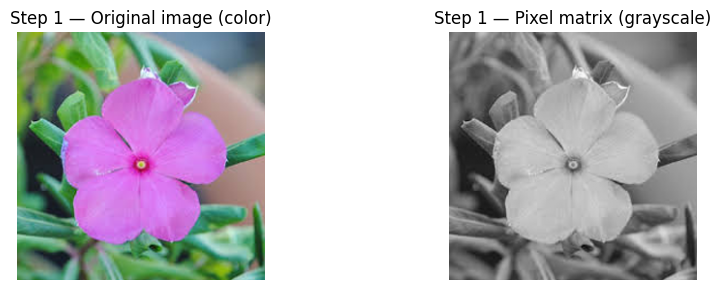

Matrix shape: (256, 256)
Sample values (top-left 4×4):
[[103.33 106.   112.   118.67]
 [104.33 107.67 113.   119.67]
 [106.   109.33 115.   121.67]
 [108.33 111.67 117.33 123.33]]


In [2]:
img = Image.open("./image1.jpeg").convert("RGB").resize((256,256))

color_array = np.array(img).astype(np.float64)
A = np.mean(color_array, axis=2) 

plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.imshow(color_array.astype(np.uint8))
plt.title("Step 1 — Original image (color)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(A, cmap="gray", vmin=0, vmax=255)
plt.title("Step 1 — Pixel matrix (grayscale)")
plt.axis("off")
plt.tight_layout()
plt.show()

print(f"Matrix shape: {A.shape}")
print(f"Sample values (top-left 4×4):\n{np.round(A[:4,:4], 2)}")

## 2. `Step 2: build kernel + apply blur`

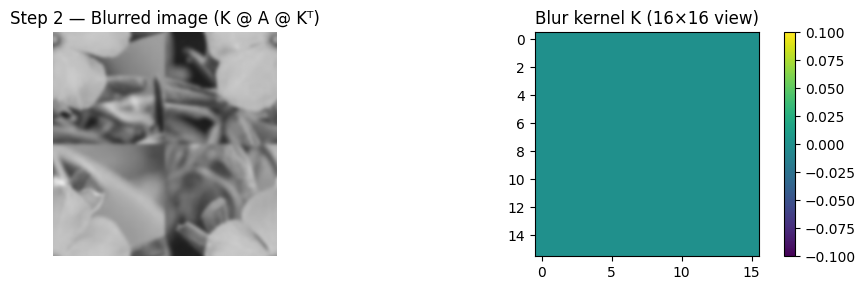

Rank: 256   Nullity: 0   Condition number: 186895766.14

RREF (top 4×4):
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]

L (LU decomp, 4×4):
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]

U (LU decomp, 4×4):
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [3]:
def build_gaussian_kernel(size, sigma=2.0):
    k = np.arange(size)
    center = size // 2
    g = np.exp(-0.5 * ((k - center) / sigma) ** 2)
    g = g / g.sum()
    K = np.zeros((size, size))
    for i in range(size):
        for j in range(size):
            K[i, j] = g[abs(i - j)]
    return K


def numpy_rref(matrix, size=4):
    M = matrix[:size, :size].astype(float).copy()
    for col in range(size):
        pivot = next((r for r in range(col, size) if abs(M[r, col]) > 1e-10), None)
        if pivot is None:
            continue
        M[[col, pivot]] = M[[pivot, col]]
        M[col] /= M[col, col]
        for row in range(size):
            if row != col:
                M[row] -= M[row, col] * M[col]
    return np.round(M, 2)


size = A.shape[0]
K = build_gaussian_kernel(size, sigma=2.0)
B = np.clip(K @ A @ K.T, 0, 255)

P_lu, L, U = lu(K[:8, :8])
rank = int(np.linalg.matrix_rank(K))
nullity = size - rank
cond = round(float(np.linalg.cond(K)), 2)
rref = numpy_rref(K)

plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.imshow(B, cmap="gray", vmin=0, vmax=255)
plt.title("Step 2 — Blurred image (K @ A @ Kᵀ)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(K[:16, :16], cmap="viridis")
plt.colorbar()
plt.title("Blur kernel K (16×16 view)")
plt.tight_layout()
plt.show()

print(f"Rank: {rank}   Nullity: {nullity}   Condition number: {cond}")
print(f"\nRREF (top 4×4):\n{rref}")
print(f"\nL (LU decomp, 4×4):\n{np.round(L[:4,:4], 3)}")
print(f"\nU (LU decomp, 4×4):\n{np.round(U[:4,:4], 3)}")

## `Step 3: Subspaces`

In [4]:
Usvd, S, Vt = np.linalg.svd(K)

col_space = Usvd[:, :rank]      
null_space = Vt[rank:]          

print(f"Rank-Nullity theorem: rank({rank}) + nullity({nullity}) = {rank+nullity} = n")
print(f"\nColumn space basis (first 3 vectors, first 4 elements):")
print(np.round(col_space[:4, :3].T, 4))
print(f"\nNull space basis (first 3 vectors, first 4 elements):")
if len(null_space) > 0:
    print(np.round(null_space[:3, :4], 4))
else:
    print("Empty — K is full rank, no null space")

Rank-Nullity theorem: rank(256) + nullity(0) = 256 = n

Column space basis (first 3 vectors, first 4 elements):
[[-0.0625 -0.0625 -0.0625 -0.0625]
 [-0.0884 -0.0884 -0.0883 -0.0881]
 [-0.     -0.0022 -0.0043 -0.0065]]

Null space basis (first 3 vectors, first 4 elements):
Empty — K is full rank, no null space


## `step 4: linear independence + basis`

In [5]:
Q_qr, R_qr = np.linalg.qr(K)
diag_R = np.abs(np.diag(R_qr))
threshold = diag_R.max() * 1e-10
independent_cols = [i for i, d in enumerate(diag_R) if d > threshold][:rank]

singular_values = np.linalg.svd(K, compute_uv=False)

print(f"Independent columns (via QR): first {len(independent_cols)} — indices {independent_cols[:8]}")
print(f"\nTop singular values: {np.round(singular_values[:6], 4)}")
print(f"\nBasis preview (rows of K at independent cols, 4×4):")
print(np.round(K[independent_cols[:4], :4], 3))

Independent columns (via QR): first 256 — indices [0, 1, 2, 3, 4, 5, 6, 7]

Top singular values: [1.     0.9988 0.9988 0.9952 0.9952 0.9892]

Basis preview (rows of K at independent cols, 4×4):
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


## `Step 5: Gram-Schmidt orthogonalization`

In [6]:
def gram_schmidt(vectors):
    basis = []
    for v in vectors:
        w = v.copy().astype(float)
        for b in basis:
            w -= np.dot(w, b) * b
        norm = np.linalg.norm(w)
        if norm > 1e-10:
            basis.append(w / norm)
    return np.array(basis)


vectors = [K[:, i] for i in range(min(rank, 10))]
ortho = gram_schmidt(vectors)

dot_check = float(np.dot(ortho[0], ortho[1]))
print(f"Vectors in: {len(vectors)}   Orthogonal vectors out: {len(ortho)}")
print(f"Dot product between first two vectors: {dot_check:.2e}")
print(f"Orthogonality confirmed: {abs(dot_check) < 1e-6}")
print(f"\nOrthogonal basis preview (3 vectors, 4 elements each):")
print(np.round(ortho[:3, :4], 4))

Vectors in: 10   Orthogonal vectors out: 10
Dot product between first two vectors: -3.89e-16
Orthogonality confirmed: True

Orthogonal basis preview (3 vectors, 4 elements each):
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


## `Step 6: Projection`

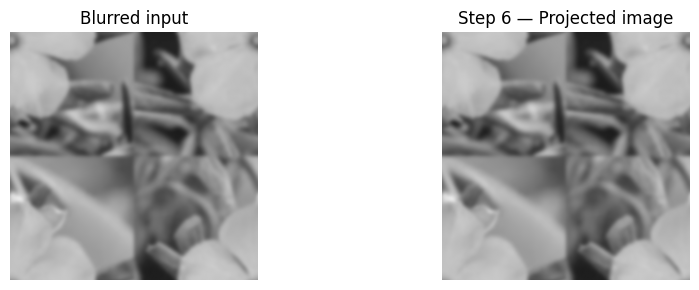

P² = P (idempotent): True
Projection matrix preview (4×4):
[[ 1. -0.  0. -0.]
 [-0.  1.  0.  0.]
 [-0.  0.  1.  0.]
 [-0. -0.  0.  1.]]


In [7]:
P_proj = K @ np.linalg.pinv(K)
projected = np.clip(P_proj @ B, 0, 255)
is_idempotent = np.allclose(P_proj @ P_proj, P_proj, atol=1e-4)

plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.imshow(B, cmap="gray", vmin=0, vmax=255)
plt.title("Blurred input")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(projected, cmap="gray", vmin=0, vmax=255)
plt.title("Step 6 — Projected image")
plt.axis("off")
plt.tight_layout()
plt.show()

print(f"P² = P (idempotent): {is_idempotent}")
print(f"Projection matrix preview (4×4):\n{np.round(P_proj[:4,:4], 4)}")

## `step 7: Least squares recovery`

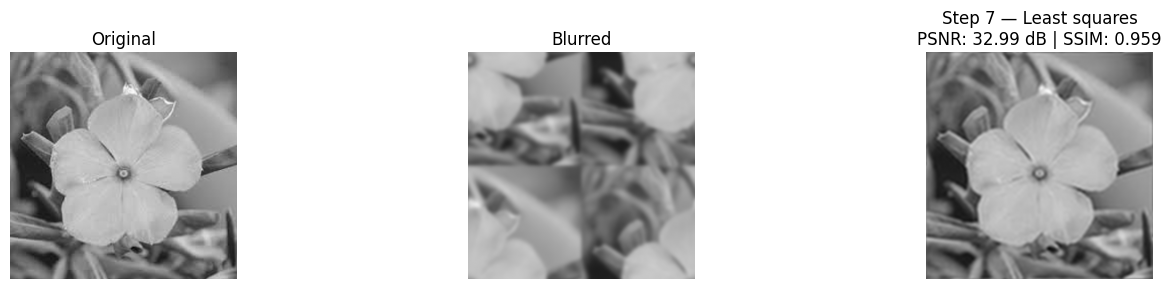

In [8]:
lam = 0.01
KtK = K.T @ K
K_reg_inv = np.linalg.solve(KtK + lam * np.eye(KtK.shape[0]), K.T)
recovered_ls = np.clip(K_reg_inv @ B @ K_reg_inv.T, 0, 255)

psnr_ls = round(float(psnr(A.astype(np.uint8), recovered_ls.astype(np.uint8), data_range=255)), 2)
ssim_ls = round(float(ssim(A.astype(np.uint8), recovered_ls.astype(np.uint8), data_range=255)), 3)

plt.figure(figsize=(15, 3))
plt.subplot(1, 3, 1)
plt.imshow(A, cmap="gray", vmin=0, vmax=255)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(B, cmap="gray", vmin=0, vmax=255)
plt.title("Blurred")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(recovered_ls, cmap="gray", vmin=0, vmax=255)
plt.title(f"Step 7 — Least squares\nPSNR: {psnr_ls} dB | SSIM: {ssim_ls}")
plt.axis("off")
plt.tight_layout()
plt.show()

## `Step 8: Eigen value analysis`

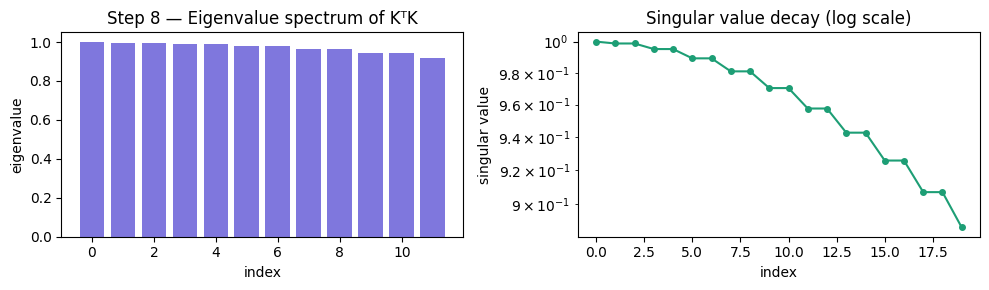

Dominant eigenvalue: 1.0
Top 8 eigenvalues: [1.0, 0.9976, 0.9976, 0.9904, 0.9904, 0.9785, 0.9785, 0.9622]
Top 8 singular values: [1.0, 0.9988, 0.9988, 0.9952, 0.9952, 0.9892, 0.9892, 0.9809]


In [9]:
KtK = K.T @ K
eigenvalues = sorted(np.linalg.eigvalsh(KtK).tolist(), reverse=True)
singular_vals = np.linalg.svd(K, compute_uv=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))

ax1.bar(range(12), eigenvalues[:12], color="#7F77DD")
ax1.set_title("Step 8 — Eigenvalue spectrum of KᵀK")
ax1.set_xlabel("index")
ax1.set_ylabel("eigenvalue")

ax2.semilogy(singular_vals[:20], color="#1D9E75", marker="o", markersize=4)
ax2.set_title("Singular value decay (log scale)")
ax2.set_xlabel("index")
ax2.set_ylabel("singular value")

plt.tight_layout()
plt.show()

print(f"Dominant eigenvalue: {round(eigenvalues[0], 4)}")
print(f"Top 8 eigenvalues: {[round(v,4) for v in eigenvalues[:8]]}")
print(f"Top 8 singular values: {[round(float(s),4) for s in singular_vals[:8]]}")

## `Step 9 : SVD reconstruction`

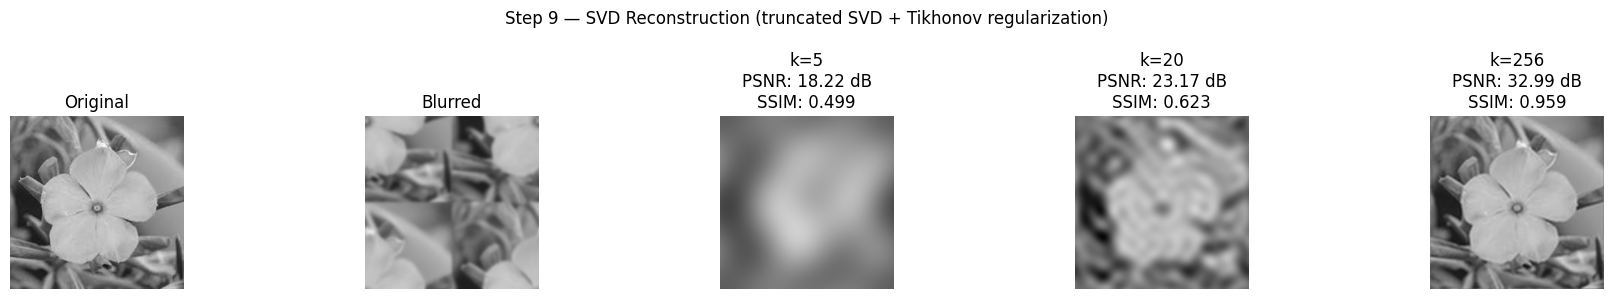

Best k: 256 → PSNR: 32.99 dB | SSIM: 0.959


In [10]:
def truncated_svd_recover(K, B, k, lam=0.01):
    U, S, Vt = np.linalg.svd(K, full_matrices=False)
    S_k, U_k, Vt_k = S[:k], U[:, :k], Vt[:k, :]
    S_inv = S_k / (S_k ** 2 + lam)     
    K_pinv = Vt_k.T @ np.diag(S_inv) @ U_k.T
    return np.clip(K_pinv @ B @ K_pinv.T, 0, 255)


k_values = [5, 20, size]
results = {}
for k in k_values:
    rec = truncated_svd_recover(K, B, k)
    results[k] = {
        "image": rec,
        "psnr": round(float(psnr(A.astype(np.uint8), rec.astype(np.uint8), data_range=255)), 2),
        "ssim": round(float(ssim(A.astype(np.uint8), rec.astype(np.uint8), data_range=255)), 3)
    }

fig, axes = plt.subplots(1, len(k_values) + 2, figsize=(18, 3))

axes[0].imshow(A, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(B, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Blurred")
axes[1].axis("off")

for i, k in enumerate(k_values):
    r = results[k]
    axes[i+2].imshow(r["image"], cmap="gray", vmin=0, vmax=255)
    axes[i+2].set_title(f"k={k}\nPSNR: {r['psnr']} dB\nSSIM: {r['ssim']}")
    axes[i+2].axis("off")

plt.suptitle("Step 9 — SVD Reconstruction (truncated SVD + Tikhonov regularization)")
plt.tight_layout()
plt.show()

best_k = max(results, key=lambda k: results[k]["psnr"])
print(f"Best k: {best_k} → PSNR: {results[best_k]['psnr']} dB | SSIM: {results[best_k]['ssim']}")

## `Final comparision:`

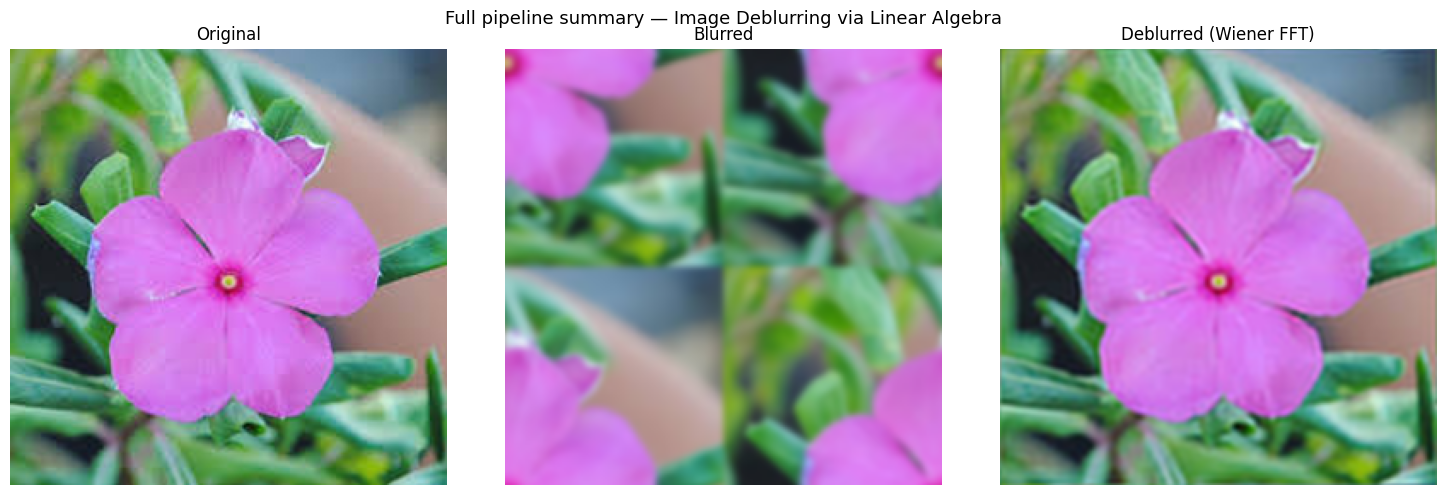

Pipeline complete.
Wiener PSNR        : 35.55 dB
Wiener SSIM        : 0.967
Least squares PSNR : 32.99 dB
Best SVD PSNR      : 32.99 dB  (k=256)


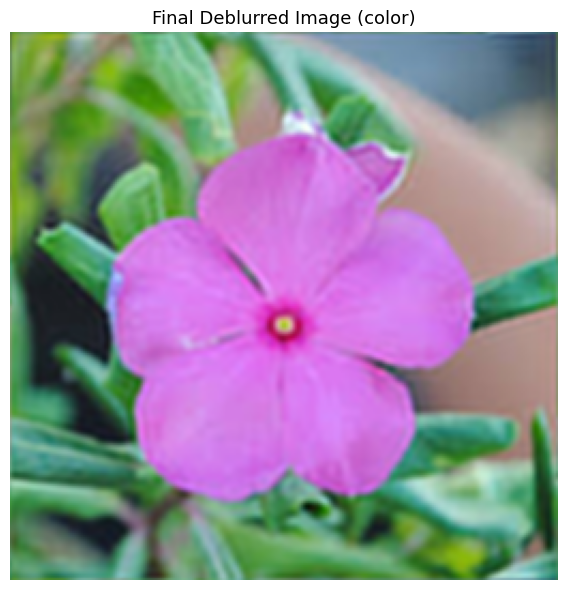

In [11]:
from numpy.fft import fft2, ifft2
from scipy.signal.windows import gaussian

def wiener_deconv_channel(blurred_ch, psf_2d, K_noise=0.01):
    """Wiener deconvolution — psf_2d must match the actual blur kernel."""
    h, w = blurred_ch.shape
    psf_centered = np.zeros((h, w))
    ph, pw = psf_2d.shape
    psf_centered[:ph, :pw] = psf_2d
    psf_centered = np.roll(psf_centered, -(ph // 2), axis=0)
    psf_centered = np.roll(psf_centered, -(pw // 2), axis=1)

    H  = fft2(psf_centered)
    Bf = fft2(blurred_ch)

    H_conj = np.conj(H)
    W = H_conj / (H_conj * H + K_noise)
    recovered = np.real(ifft2(W * Bf))
    return np.clip(recovered, 0, 255)

# ── Build compact 2D PSF ─────────────────────────────────────────────────────
kernel_size = 13
g1d = gaussian(kernel_size, std=2.0)
g1d /= g1d.sum()

psf_small = np.outer(g1d, g1d)
psf_small /= psf_small.sum()

psf_2d_true = np.zeros((size, size))
psf_2d_true[:kernel_size, :kernel_size] = psf_small
psf_2d_true = np.roll(psf_2d_true, -(kernel_size // 2), axis=0)
psf_2d_true = np.roll(psf_2d_true, -(kernel_size // 2), axis=1)

# ── Blur color image ─────────────────────────────────────────────────────────
color_float = color_array.astype(np.float64)
blurred_color = np.stack([
    np.clip(K @ color_float[:,:,c] @ K.T, 0, 255)
    for c in range(3)
], axis=2)

# ── Deblur each channel ──────────────────────────────────────────────────────
deblurred_color = np.stack([
    wiener_deconv_channel(blurred_color[:,:,c], psf_2d_true, K_noise=0.001)
    for c in range(3)
], axis=2).astype(np.uint8)

# ── Metrics ──────────────────────────────────────────────────────────────────
gray_orig      = A.astype(np.uint8)
gray_deblurred = np.mean(deblurred_color.astype(np.float64), axis=2).astype(np.uint8)

psnr_wiener = round(float(psnr(gray_orig, gray_deblurred, data_range=255)), 2)
ssim_wiener = round(float(ssim(gray_orig, gray_deblurred, data_range=255)), 3)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(color_array.astype(np.uint8))
axes[0].set_title("Original", fontsize=12)
axes[0].axis("off")

axes[1].imshow(blurred_color.astype(np.uint8))
axes[1].set_title("Blurred", fontsize=12)
axes[1].axis("off")

axes[2].imshow(deblurred_color)
axes[2].set_title("Deblurred (Wiener FFT)", fontsize=12)
axes[2].axis("off")

plt.suptitle("Full pipeline summary — Image Deblurring via Linear Algebra", fontsize=13)
plt.tight_layout()
plt.savefig("final_deblurred_output.png", dpi=150, bbox_inches="tight")
plt.show()

deblurred_pil = Image.fromarray(deblurred_color, mode="RGB")
deblurred_pil.save("best_deblurred_image.png")

print("Pipeline complete.")
print(f"Wiener PSNR        : {psnr_wiener} dB")
print(f"Wiener SSIM        : {ssim_wiener}")
print(f"Least squares PSNR : {psnr_ls} dB")
print(f"Best SVD PSNR      : {results[best_k]['psnr']} dB  (k={best_k})")

plt.figure(figsize=(6, 6))
plt.imshow(deblurred_color)
plt.title("Final Deblurred Image (color)", fontsize=13)
plt.axis("off")
plt.tight_layout()
plt.show()